In [50]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

In [17]:
data=np.load('/Users/simoneabeni/Desktop/GitHub/reps/astrostatistics_bicocca_2026/solutions/formationchannels.npy')
np.shape(data)

(2950, 1)

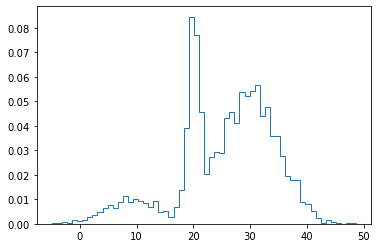

In [77]:
plt.hist(data,histtype='step',bins=60,density=True);
plt.show()

In [36]:
gm = GaussianMixture(5).fit(data)
gm.means_
gm.aic(data)

20112.975200005843

In [46]:
#compute aic
N=10
aic = np.empty(N)
for i in np.arange(1,N+1):
    aic[i-1] = GaussianMixture(i).fit(data).aic(data)
np.min(aic)
print(GaussianMixture(3).fit(data))

GaussianMixture(n_components=3)


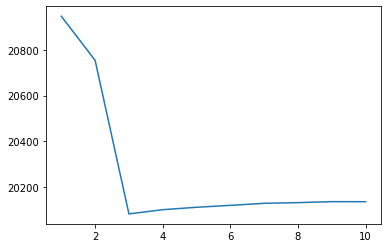

In [41]:
#aic vs. N
plt.plot(np.arange(1,N+1),aic);
plt.xlab
plt.show()

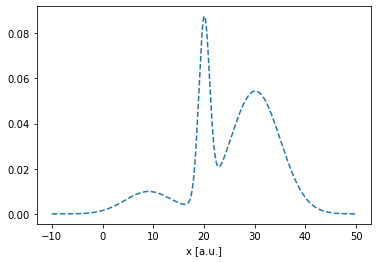

In [111]:
xgrid = np.linspace(-10,50,10**5)
gm3 = GaussianMixture(3).fit(data) 
gm3_means=gm3.means_.flatten() #array of means
gm3_dev=((gm3.covariances_)**0.5).flatten() #array of sigmas
gm3_weights=gm3.weights_.flatten() #array of weights
y = np.array([w*norm.pdf(xgrid,loc=x_0,scale=s) for (w,x_0,s) in zip(gm3_weights,gm3_means,gm3_dev)])
Y=np.sum(y,axis=0,keepdims=True).flatten()
fig, ax = plt.subplots()
#for yi in Y:
plt.plot(xgrid,Y,ls='--')
#for yi in y:
    #plt.plot(xgrid,yi,ls='--')
plt.xlabel('x [a.u.]')
plt.show()